In [6]:
# Core
import pandas as pd
import numpy as np

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Optional: XGBoost (uncomment if installed)
# from xgboost import XGBRegressor, XGBClassifier

# Explainability
import shap
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("corporate_projects.csv")

# Basic checks
print(df.shape)
df.head()

(50, 10)


,Project_ID,Department,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Project_Risk,Success
0,1,Operations,184654,583556,2348816,1888756,0.08,0.05,Low,0
1,2,Marketing,2054354,1447527,541234,278576,0.15,-0.01,Low,1
2,3,Finance,2516182,1372905,1998260,2312990,0.19,0.02,High,1
3,4,Operations,3574675,1817640,189182,1434250,0.22,0.10,Medium,1
4,5,Operations,2752991,792139,1571101,111087,0.12,0.09,High,0


In [8]:
# Map risk to numeric
risk_map = {"Low": 1, "Medium": 2, "High": 3}
df["Project_Risk_Num"] = df["Project_Risk"].map(risk_map)

# Features & targets
features = [
    "Department",
    "Investment_Cost",
    "Historical_ROI",
    "Market_Growth",
    "Project_Risk_Num"
]

target_success = "Success"
target_cf = [
    "Expected_Cashflow_Year1",
    "Expected_Cashflow_Year2",
    "Expected_Cashflow_Year3"
]

X = df[features]
y_success = df[target_success]
y_cf = df[target_cf]

In [9]:
X_train, X_test, y_s_train, y_s_test = train_test_split(
    X, y_success, test_size=0.2, random_state=42
)

_, _, y_cf_train, y_cf_test = train_test_split(
    X, y_cf, test_size=0.2, random_state=42
)

In [10]:
categorical = ["Department"]
numerical = ["Investment_Cost", "Historical_ROI", "Market_Growth", "Project_Risk_Num"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", "passthrough", numerical)
])

## Cash Flow Forecast via Regression

## Random Forest Regressor

In [11]:
reg_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42))
])

reg_model.fit(X_train, y_cf_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Department']),
                                                 ('num', 'passthrough',
                                                  ['Investment_Cost',
                                                   'Historical_ROI',
                                                   'Market_Growth',
                                                   'Project_Risk_Num'])])),
                ('model',
                 RandomForestRegressor(max_depth=6, n_estimators=200,
                                       random_state=42))])

## XGBoost

In [12]:
# reg_model = Pipeline([
#     ("prep", preprocessor),
#     ("model", XGBRegressor(n_estimators=200, learning_rate=0.05))
# ])
# reg_model.fit(X_train, y_cf_train)

## Success Probability (Classification)

In [13]:
clf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))
])

clf_model.fit(X_train, y_s_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Department']),
                                                 ('num', 'passthrough',
                                                  ['Investment_Cost',
                                                   'Historical_ROI',
                                                   'Market_Growth',
                                                   'Project_Risk_Num'])])),
                ('model',
                 RandomForestClassifier(max_depth=6, n_estimators=200,
                                        random_state=42))])

## Model Evaluation

In [14]:
# Regression RMSE
pred_cf_test = reg_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_cf_test, pred_cf_test))
print("RMSE (cashflow):", rmse)

# Classification AUC
pred_prob_test = clf_model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_s_test, pred_prob_test)
print("AUC (success):", auc)

RMSE (cashflow): 868701.2712626134
AUC (success): 0.6400000000000001


## Predictions

In [15]:
# Cashflows
pred_cf = reg_model.predict(X)
df["Pred_CF1"] = pred_cf[:,0]
df["Pred_CF2"] = pred_cf[:,1]
df["Pred_CF3"] = pred_cf[:,2]

# Success probability
df["Success_Prob"] = clf_model.predict_proba(X)[:,1]

# NPV, EV, Risk Adjusted Return

In [16]:
WACC = 0.10  # 10%

def compute_npv(row):
    cf1, cf2, cf3 = row["Pred_CF1"], row["Pred_CF2"], row["Pred_CF3"]
    inv = row["Investment_Cost"]
    return (cf1/(1+WACC)) + (cf2/(1+WACC)**2) + (cf3/(1+WACC)**3) - inv

df["NPV"] = df.apply(compute_npv, axis=1)

# Expected Value (risk-adjusted)
df["EV"] = df["NPV"] * df["Success_Prob"]

# Efficiency metric
df["EV_to_Investment"] = df["EV"] / df["Investment_Cost"]

## Ranking Projects

In [17]:
ranked_df = df.sort_values(by="EV", ascending=False)

top_projects = ranked_df[[
    "Project_ID",
    "NPV",
    "Success_Prob",
    "EV",
    "EV_to_Investment"
]].head(10)

top_projects

,Project_ID,NPV,Success_Prob,EV,EV_to_Investment
34,35,3.556388e+06,0.795000,2.827329e+06,9.527035
42,43,3.172736e+06,0.847520,2.688957e+06,4.045460
48,49,3.153002e+06,0.611833,1.929112e+06,15.652402
44,45,2.258386e+06,0.736611,1.663552e+06,1.178373
40,41,1.889513e+06,0.826426,1.561543e+06,0.927063
38,39,2.122048e+06,0.726095,1.540808e+06,1.343575
30,31,3.142510e+06,0.466710,1.466640e+06,3.944320
2,3,1.413840e+06,0.870494,1.230739e+06,0.489130
14,15,1.385612e+06,0.759384,1.052211e+06,0.672044
45,46,1.955327e+06,0.512599,1.002298e+06,0.905179


## Decision Rules

In [23]:
def decision(row):
    if row["NPV"] > 0 and row["Success_Prob"] > 0.7:
        return "Fund"
    elif row["NPV"] > 0:
        return "Review"
    else:
        return "Reject"

df["Decision"] = df.apply(decision, axis=1)
ranked_df = df.sort_values(by="EV", ascending=False)
df["Decision"].value_counts()

,count
Decision,
Reject,21
Fund,15
Review,14


## SHAP Explainibility

In [73]:
X_transformed = clf_model.named_steps["prep"].transform(X)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

feature_names = clf_model.named_steps["prep"].get_feature_names_out()

X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

rf_model = clf_model.named_steps["model"]

# Step 2: Use new explainer (IMPORTANT CHANGE)
explainer = shap.Explainer(rf_model.predict_proba, X_transformed_df)

shap_values = explainer(
    X_transformed_df
)

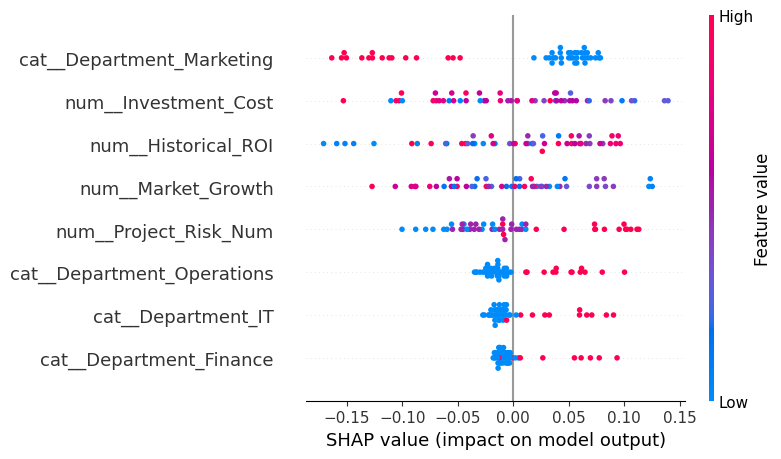

In [74]:
shap.summary_plot(shap_values[:, :, 1], X_transformed_df)

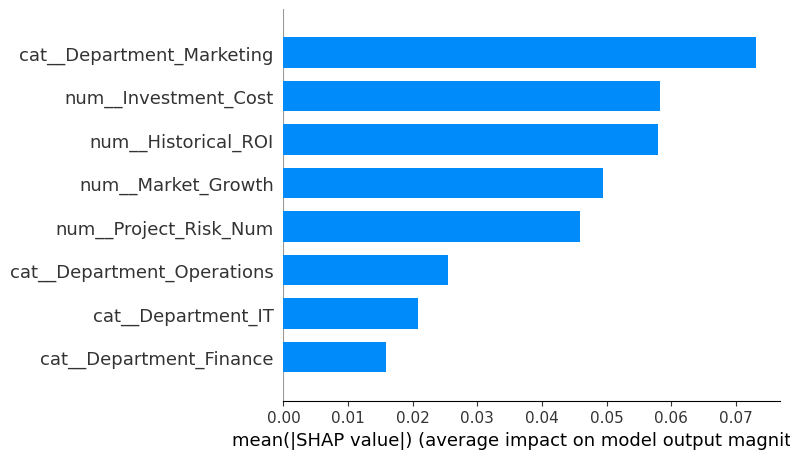

In [78]:
shap.summary_plot(shap_values[:,:,1], X_transformed_df, plot_type="bar")

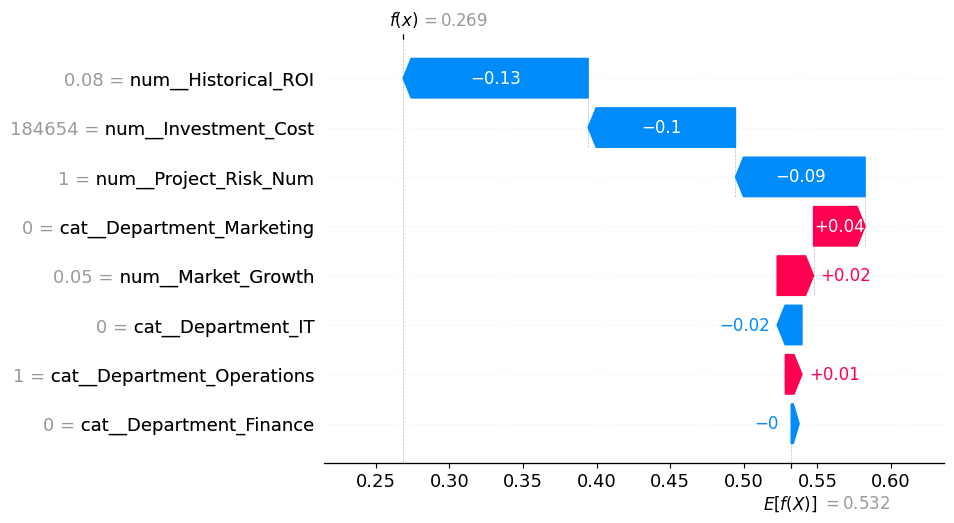

In [80]:
shap.plots.waterfall(shap_values[0, :, 1])

#1. Global Drivers (Bar Plot)
**What it shows:**

Feature importance across all projects

**🔥 Key Insights:**
**1. Marketing projects dominate**
    - Department_Marketing is the strongest driver

    👉 “Marketing initiatives have the highest success likelihood”
**2. Investment Cost is highly influential**
    - Not direction → but importance

  👉 “Capital allocation size significantly impacts outcomes”

**3. Historical ROI is critical**
    
    👉 “Past performance is a strong predictor of future success”

**4. Market Growth matters**

  👉 “External industry conditions materially affect project viability”

**5. Risk matters (negatively)**

  👉 “Higher risk reduces success probability”

# 🔷 2. Directional Insights (Beeswarm Plot)

This is where you show **cause-effect**, not just importance.

🔥 Key Business Interpretations:

### ✅ Positive Drivers (push success ↑)
- High **Market Growth**
- High **Historical ROI**
- Marketing-related projects

### ❌ Negative Drivers (push success ↓)
- High Project Risk
- Some high-cost projects (without support)

---


💡 Most important insight:

“Investment cost alone is not predictive — it must be supported by strong ROI and favorable market conditions.”

👉 This is a very strong finance insight

---

# 🔷 3. Individual Decision (Waterfall Plot)


**What happened in this project:**

**❌ Negative factors:**
- Historical ROI → -0.13
- Investment Cost → -0.10
- Risk → -0.09

**✅ Positive factors:**
- Marketing → +0.04
- Market Growth → +0.02
---

**🧠 Final interpretation:**

“Despite being in a favorable department and moderate market growth, the project is penalized by low historical ROI, high investment cost, and risk — leading to lower success probability.”

---


## Executive Summary

In [24]:
summary = {}

summary["Total Projects"] = len(df)
summary["Fund"] = (df["Decision"] == "Fund").sum()
summary["Review"] = (df["Decision"] == "Review").sum()
summary["Reject"] = (df["Decision"] == "Reject").sum()

summary["Avg EV (Funded)"] = df[df["Decision"]=="Fund"]["EV"].mean()

summary

{'Total Projects': 50,
 'Fund': np.int64(15),
 'Review': np.int64(14),
 'Reject': np.int64(21),
 'Avg EV (Funded)': np.float64(1085390.585944291)}

## Top Recommendations

In [25]:
final_recommendations = ranked_df[ranked_df["Decision"]=="Fund"].head(10)

final_recommendations

,Project_ID,Department,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Project_Risk,Success,Project_Risk_Num,Pred_CF1,Pred_CF2,Pred_CF3,Success_Prob,NPV,EV,EV_to_Investment,Decision
34,35,IT,296769,1806187,2173091,731669,0.23,-0.03,Medium,1,2,1.570979e+06,1.868431e+06,1.172394e+06,0.795000,3.556388e+06,2.827329e+06,9.527035,Fund
42,43,IT,664685,963910,2285000,2068163,0.24,0.14,Medium,1,2,1.002526e+06,1.750961e+06,1.968494e+06,0.847520,3.172736e+06,2.688957e+06,4.045460,Fund
44,45,Marketing,1411736,1700237,1677880,1711909,0.11,-0.01,Low,1,1,1.542167e+06,1.361071e+06,1.521732e+06,0.736611,2.258386e+06,1.663552e+06,1.178373,Fund
40,41,Operations,1684398,888688,1034346,2608231,0.12,0.03,Medium,1,2,9.521297e+05,1.297021e+06,2.178075e+06,0.826426,1.889513e+06,1.561543e+06,0.927063,Fund
38,39,Finance,1146797,1046107,125766,2958926,0.18,0.05,Low,1,1,9.554005e+05,6.694814e+05,2.458369e+06,0.726095,2.122048e+06,1.540808e+06,1.343575,Fund
2,3,Finance,2516182,1372905,1998260,2312990,0.19,0.02,High,1,3,1.118631e+06,1.718828e+06,1.986606e+06,0.870494,1.413840e+06,1.230739e+06,0.489130,Fund
14,15,Marketing,1565689,352918,2066716,815313,0.19,0.04,High,1,3,6.302490e+05,1.680599e+06,1.316921e+06,0.759384,1.385612e+06,1.052211e+06,0.672044,Fund
27,28,IT,1873415,1227888,93585,1356002,0.23,0.13,Medium,1,2,1.162080e+06,6.963739e+05,1.626408e+06,0.845645,9.804811e+05,8.291388e+05,0.442581,Fund
35,36,Finance,2758505,1383382,2059021,1169043,0.22,0.01,Medium,1,2,1.265628e+06,1.545340e+06,1.449171e+06,0.775668,7.579906e+05,5.879492e+05,0.213141,Fund
9,10,IT,2670406,1660908,947421,1936013,0.07,0.00,High,1,3,1.418528e+06,1.062696e+06,1.562707e+06,0.792500,6.715111e+05,5.321725e+05,0.199285,Fund


“We built an ML model to predict project success and cash flows, then translated those into financial metrics like NPV and expected value. Using SHAP, we identified that market growth and historical ROI are key drivers, while project risk negatively impacts outcomes. This allows Aurora Finance to allocate capital more efficiently by funding projects that are both high-return and high-probability.”